# Análisis Basado en Eventos ⁉️

## Paso 1. Cargar librerías y Datos

In [27]:
import pandas as pd
import numpy as np
import plotly.express as px
from matplotlib import pyplot as plt
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest

In [28]:
df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\\t', engine='python')
print(df.head(), '\n')
print(df.info())

                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None


## Paso 2. Preparar datos para el Análisis

In [29]:
# Se cambiará el nombre de las columnas de formato PascalCase a snake_case
df.columns = ['event_name', 'user_id', 'event_timestamp', 'exp_id']

In [30]:
# Explorar los datos para verificar si hay valores ausentes, nulos o incorrectos
print(df['event_name'].unique(), '\n', df['event_name'].describe(), '\n --------------------')
print(df['user_id'].describe(), '\n --------------------')
print(df['event_timestamp'].describe(), '\n --------------------')
print(df['exp_id'].unique(), '\n', df['exp_id'].describe())

['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial'] 
 count               244126
unique                   5
top       MainScreenAppear
freq                119205
Name: event_name, dtype: object 
 --------------------
count    2.441260e+05
mean     4.627568e+18
std      2.642425e+18
min      6.888747e+15
25%      2.372212e+18
50%      4.623192e+18
75%      6.932517e+18
max      9.222603e+18
Name: user_id, dtype: float64 
 --------------------
count    2.441260e+05
mean     1.564914e+09
std      1.771343e+05
min      1.564030e+09
25%      1.564757e+09
50%      1.564919e+09
75%      1.565075e+09
max      1.565213e+09
Name: event_timestamp, dtype: float64 
 --------------------
[246 248 247] 
 count    244126.000000
mean        247.022296
std           0.824434
min         246.000000
25%         246.000000
50%         247.000000
75%         248.000000
max         248.000000
Name: exp_id, dtype: float64


In [31]:
# Convertir Timestapm de formato Epoch Unix a UTC con fecha y hora
df['timestamp'] = pd.to_datetime(df['event_timestamp'], unit='s')

# Crear la columna 'Date' que contenga unicamente la fecha
df['date'] = df['timestamp'].astype('datetime64[D]')

# Corroborar el resultado
print(df['timestamp'].head())
print()
print(df['date'].head())

0   2019-07-25 04:43:36
1   2019-07-25 11:11:42
2   2019-07-25 11:28:47
3   2019-07-25 11:28:47
4   2019-07-25 11:48:42
Name: timestamp, dtype: datetime64[ns]

0   2019-07-25
1   2019-07-25
2   2019-07-25
3   2019-07-25
4   2019-07-25
Name: date, dtype: datetime64[ns]


## Paso 3. Estudiar y comprobar los Datos

In [32]:
# Responder las preguntas
# ¿Cuántos eventos hay en los registros?
print('El total de eventos únicos en los registros es:' , df['event_name'].nunique())
print('El total de eventos en los registros es: {:,}'.format(df['event_name'].count()))

# ¿Cuántos usuarios hay en los registros?
print('El total de usuarios únicos en los registros es: {:,}'.format(df['user_id'].nunique()))

# ¿Cuál es el promedio de eventos por usuario?
print('El promedio de eventos por usuario es: {:.2f}'.format(df.groupby('user_id').agg({'event_name':'count'}).mean()[0]))

El total de eventos únicos en los registros es: 5
El total de eventos en los registros es: 244,126
El total de usuarios únicos en los registros es: 7,551
El promedio de eventos por usuario es: 32.33


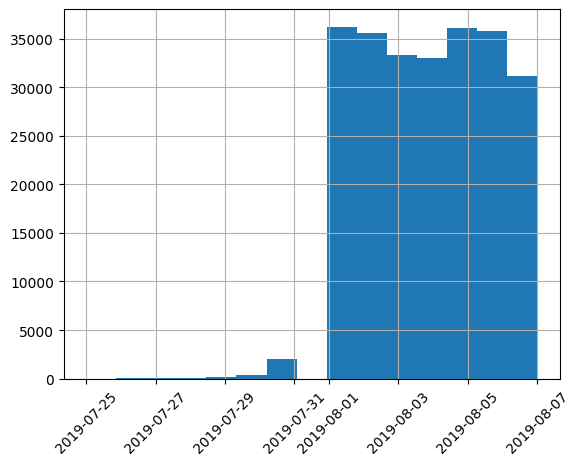

In [33]:
# ¿Qué periodo de tiempo cubren los datos? 
# ¿Puedes tener seguridad de que tienes datos igualmente completos para todo el periodo?
# ¿Qué periodo representan realmente los datos?
df['date'].hist(bins=15)
plt.xticks(rotation=45)
plt.show()


In [34]:
np.percentile(df['timestamp'], [0, 1, 5, 10])

array(['2019-07-25T04:43:36.000000000', '2019-07-31T22:02:36.000000000',
       '2019-08-01T09:28:20.250000000', '2019-08-01T14:37:06.500000000'],
      dtype='datetime64[ns]')

<b>NOTA:<b>

Menos del 5% de los eventos registrados en el DataFrame pertenecen al mes de julio (07)

In [35]:
# Eliminar los datos entre el 25-07-2019 y el 31-07-2019
df_filtered = df[np.logical_not(df['date'] < '2019-08-01')]
print(df_filtered['date'].describe())
print()
print('Cantidad de celdas eliminadas: ', len(df[df['date'] < '2019-08-01']))
print('Lo cual representa el {:.2f}% de las filas del DataFrame'.format((len(df[df['date'] < '2019-08-01']) / len(df))*100) )

count                  241298
unique                      7
top       2019-08-01 00:00:00
freq                    36229
first     2019-08-01 00:00:00
last      2019-08-07 00:00:00
Name: date, dtype: object

Cantidad de celdas eliminadas:  2828
Lo cual representa el 1.16% de las filas del DataFrame


In [36]:
# Asegurate de tener usuarios de los tres grupos experimentales
print(df_filtered.groupby('exp_id').agg({'event_name':'count', 'user_id':'nunique'}))
print()
# Verificar la cantidad de usuarios en el DataFrame limpio
print(df_filtered['user_id'].nunique())

        event_name  user_id
exp_id                     
246          79425     2484
247          77147     2513
248          84726     2537

7534


<b> CONCLUSIONES INTERMEDIAS <b>

- Encontramos en el DataFrame `5 eventos` a los cuales podían acceder los usuarios.
- Se decidió eliminar del DataFrame los registros ocurridos antes del `1 de agosto de 2018`, ya que representaban aproximadamente el `1.16%` de los datos y se notaba una diferencia muy considerable en el tráfico de usuarios antes y después de esa fecha.
- Una vez eliminado los registros del mes de julio, en los registros hay un total de `7,534` usuarios, repartidos de la siguiente manera: `2,484` en el `grupo 246`, `2,513` en el `grupo 247` y `2,537` en el `grupo 248`
- El promedio de eventos que registran los usuarios es de `32.33` eventos.

## Paso 4. Estudiar el embudo de eventos

In [37]:
# Agrupar los registros por el nombre del evento
events_funnel = df_filtered.groupby('event_name', as_index=False).agg({'event_timestamp':'count', 'user_id':'nunique'}).sort_values('event_timestamp', ascending=False)
events_funnel.columns = ['event_name', 'events_count', 'users_count']

# Crear columna de proporcion de usuarios
events_funnel['proportion'] = (events_funnel['users_count'] / events_funnel['users_count'].max()).round(3)
events_funnel

,event_name,events_count,users_count,proportion
1,MainScreenAppear,117431,7419,1.000
2,OffersScreenAppear,46350,4593,0.619
0,CartScreenAppear,42365,3734,0.503
3,PaymentScreenSuccessful,34113,3539,0.477
4,Tutorial,1039,840,0.113


<b> NOTA: <b>

Todo parece indicar que el evento `Tutorial` no es parte de la secuencia de eventos que siguen los usuarios, mas bien, es un evento opcional al cual acceden aproximadamente el 11% de los usuarios, siendo este el evento con la proporción más pequeña de usuarios.

Para el resto de los eventos, su proporción de usuarios va decendiendo en una secuencia lógica, desde el evento `MainScrenAppear` con un 100% de los usuarios hasta el evento `PaymentScreenSuccessful` con un 47% de los usuarios, por lo que no tendría sentido que en medio de esos dos eventos hubiera un paso obligatorio que solo tuviera un 11% de los usuarios, ni tampoco tiene sentido que el tutorial venga después del pago.

Por todo esto, se decide eliminar el evento `Tutorial` del embudo de eventos.

In [38]:
# Se eliminará el Evento Tutorial ya que no forma parte del Embudo de eventos
events_funnel = events_funnel.drop(index=4).reset_index(drop=True)

# Calcular el porcentaje de usuarios que se piereden de un evento a otro
events_funnel['users_lost'] = events_funnel['proportion'] - events_funnel['proportion'].shift(1)

# Rellenar el valor NaN que surge en la primera fila
events_funnel['users_lost'] = events_funnel['users_lost'].fillna(0)
events_funnel

,event_name,events_count,users_count,proportion,users_lost
0,MainScreenAppear,117431,7419,1.000,0.000
1,OffersScreenAppear,46350,4593,0.619,-0.381
2,CartScreenAppear,42365,3734,0.503,-0.116
3,PaymentScreenSuccessful,34113,3539,0.477,-0.026


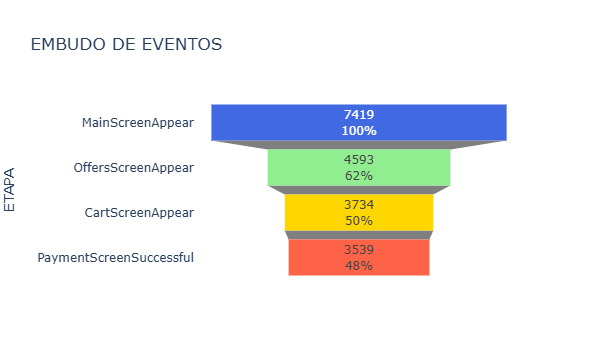

In [39]:
# Graficar el funnel
fig = px.funnel(
    events_funnel,
    x= 'users_count', 
    y= 'event_name',
    text= 'users_count',
    template= 'plotly_white',
    title= 'EMBUDO DE EVENTOS',
    labels={'event_name': 'ETAPA', 'users_count': 'USUARIOS'}
)
fig.update_traces(
    textinfo="value+percent initial",
    marker_color=['royalblue', 'lightgreen', 'gold', 'tomato'])
fig.show()

<b> CONCLUSIONES INTERMEDIAS: <b>

- La etapa con más usuarios es `MainScreenAppear`con 7,419, de los 7,534 que contabilizamos en la columna 'user_id'. Para fines prácticos consideraremos los 7,419 usuarios que tuvieron el evento 'MainScreenAppear' como el 100% de los usuarios e iremos restando la proporción a partir de ese 100%.
- La etapa dónde se pierden más usuarios es en `OffersScreenAppear`, donde se pierde un 38.1% de los usuarios.
- En las siguientes 2 etapas se pierde menos del 12% de los usuarios.
- De los 7,419 usuarios que iniciaron el recorrido, el `48%` (3,539 usuarios) llegan hasta el pago ('PaymentScreenSuccessful')

## Paso 5. Estudio de los resultados del experimento

### 5.1. Análisis de los embudos por experimento

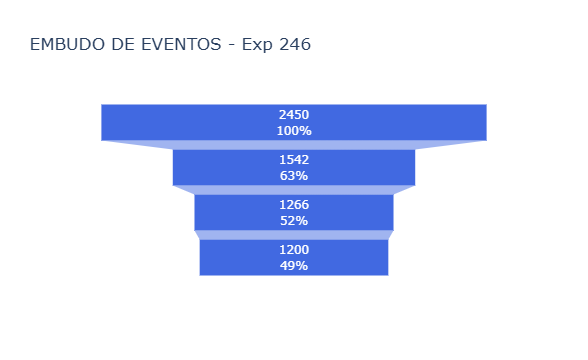

                event_name  users_count  proportion  users_lost
3         MainScreenAppear         2450       1.000       0.000
6       OffersScreenAppear         1542       0.629      -0.371
0         CartScreenAppear         1266       0.517      -0.112
9  PaymentScreenSuccessful         1200       0.490      -0.027


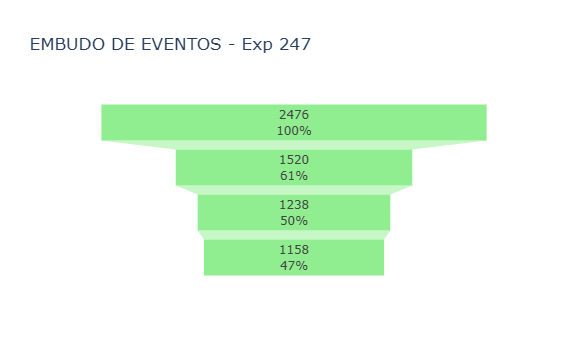

                 event_name  users_count  proportion  users_lost
4          MainScreenAppear         2476       1.000       0.000
7        OffersScreenAppear         1520       0.614      -0.386
1          CartScreenAppear         1238       0.500      -0.114
10  PaymentScreenSuccessful         1158       0.468      -0.032


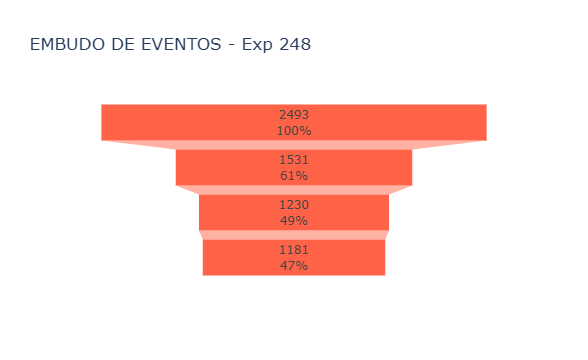

                 event_name  users_count  proportion  users_lost
5          MainScreenAppear         2493       1.000       0.000
8        OffersScreenAppear         1531       0.614      -0.386
2          CartScreenAppear         1230       0.493      -0.121
11  PaymentScreenSuccessful         1181       0.474      -0.019


In [40]:
# Analisis por grupo
# Cuantos usuarios hay en cada grupo
events_by_group = df_filtered.groupby(['event_name', 'exp_id'], as_index=False).agg({'event_timestamp':'count', 'user_id':'nunique'}).sort_values(['user_id'], ascending=False)
events_by_group.columns = ['event_name', 'exp_id', 'events_count', 'users_count']

# Eliminar el evento 'Tutorial'
events_by_group = events_by_group[np.logical_not(events_by_group['event_name'] == 'Tutorial')]

# Dividir por 'ExpId'
funnel_246 = events_by_group[events_by_group['exp_id'] == 246].sort_values('users_count', ascending=False)
funnel_247 = events_by_group[events_by_group['exp_id'] == 247].sort_values('users_count', ascending=False)
funnel_248 = events_by_group[events_by_group['exp_id'] == 248].sort_values('users_count', ascending=False)

# Crear columnas 'Proportion' y 'UserLost'
funnel_246['proportion'] = (funnel_246['users_count'] / funnel_246['users_count'].max()).round(3)
funnel_246['users_lost'] = funnel_246['proportion'] - funnel_246['proportion'].shift(1)
funnel_246['users_lost'] = funnel_246['users_lost'].fillna(0)

funnel_247['proportion'] = (funnel_247['users_count'] / funnel_247['users_count'].max()).round(3)
funnel_247['users_lost'] = funnel_247['proportion'] - funnel_247['proportion'].shift(1)
funnel_247['users_lost'] = funnel_247['users_lost'].fillna(0)

funnel_248['proportion'] = (funnel_248['users_count'] / funnel_248['users_count'].max()).round(3)
funnel_248['users_lost'] = funnel_248['proportion'] - funnel_248['proportion'].shift(1)
funnel_248['users_lost'] = funnel_248['users_lost'].fillna(0)

# Graficar Embudos
# -------------------- Exp 246 --------------------
fig_246 = px.funnel(
    funnel_246,
    x= 'users_count', 
    y= 'event_name',
    text= 'users_count',
    template= 'plotly_white',
    title= 'EMBUDO DE EVENTOS - Exp 246',
    labels={'event_name': 'ETAPA', 'users_count': 'USUARIOS'}
)
fig_246.update_traces(textinfo="value+percent initial", marker_color= 'Royalblue')
fig_246.update_yaxes(visible=False)
fig_246.show()
print(funnel_246[['event_name', 'users_count', 'proportion', 'users_lost']])

# -------------------- Exp 247 --------------------
fig_247 = px.funnel(
    funnel_247,
    x= 'users_count', 
    y= 'event_name',
    text= 'users_count',
    template= 'plotly_white',
    title= 'EMBUDO DE EVENTOS - Exp 247',
    labels={'event_name': 'ETAPA', 'users_count': 'USUARIOS'}
)
fig_247.update_traces(textinfo="value+percent initial", marker_color= 'lightgreen')
fig_247.update_yaxes(visible=False)
fig_247.show()
print(funnel_247[['event_name', 'users_count', 'proportion', 'users_lost']])

# -------------------- Exp 248 --------------------
fig_248 = px.funnel(
    funnel_248,
    x= 'users_count', 
    y= 'event_name',
    text= 'users_count',
    template= 'plotly_white',
    title= 'EMBUDO DE EVENTOS - Exp 248',
    labels={'event_name': 'ETAPA', 'users_count': 'USUARIOS'}
)
fig_248.update_traces(textinfo="value+percent initial", marker_color= 'tomato')
fig_248.update_yaxes(visible=False)
fig_248.show()
print(funnel_248[['event_name', 'users_count', 'proportion', 'users_lost']])

In [41]:
# Cuantos usuarios hay en cada grupo
print('En el grupo 246 hay' , df_filtered[df_filtered['exp_id'] == 246]['user_id'].nunique(), 'usuarios')
print('En el grupo 247 hay' , df_filtered[df_filtered['exp_id'] == 247]['user_id'].nunique(), 'usuarios')
print('En el grupo 248 hay' , df_filtered[df_filtered['exp_id'] == 248]['user_id'].nunique(), 'usuarios')


En el grupo 246 hay 2484 usuarios
En el grupo 247 hay 2513 usuarios
En el grupo 248 hay 2537 usuarios


### 5.2. Análisis de prueba Z

<b>Función para realizar un Z_Test<b>

In [42]:
# Función auxiliar elaborada en el Webibar del Sprint
def z_test_check(df, group1_id, group2_id, event_name, alpha=0.05):
    # 1. Obtener usuarios totales en cada grupo
    n_users = df.groupby('exp_id')['user_id'].nunique()
    # n_obs_1 = n_users[group1_id]
    if isinstance(group1_id, int):
        n_obs_1 = n_users[group1_id]
    elif isinstance(group1_id, list):
        n_obs_1 = n_users[group1_id[0]] + n_users[group1_id[1]]
    n_obs_2 = n_users[group2_id]

    # 2. Obtener usuarios que realizaron el evento en cada grupo
    successes = df[df['event_name'] == event_name].groupby('exp_id')['user_id'].nunique()
    # success_1 = successes.get(group1_id, 0)
    if isinstance(group1_id, int):
        success_1 = successes[group1_id]
    elif isinstance(group1_id, list):
        success_1 = successes[group1_id[0]] + successes[group1_id[1]]
    success_2 = successes[group2_id]

    
# 3. Prueba Z
    stat, p_value = proportions_ztest([success_1, success_2], [n_obs_1, n_obs_2])


    # 4. Impresión de los resultados
    print(f"Grupos: {group1_id} vs {group2_id}")
    print(f"Evento: {event_name} | p-value: {p_value:.4f}")
    if p_value < alpha:
        print("   🚨 ¡Diferencia Significativa detectada!")
    else:
        print("   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)")

<b>¿Hay una diferencia entre los grupos de control A/A?

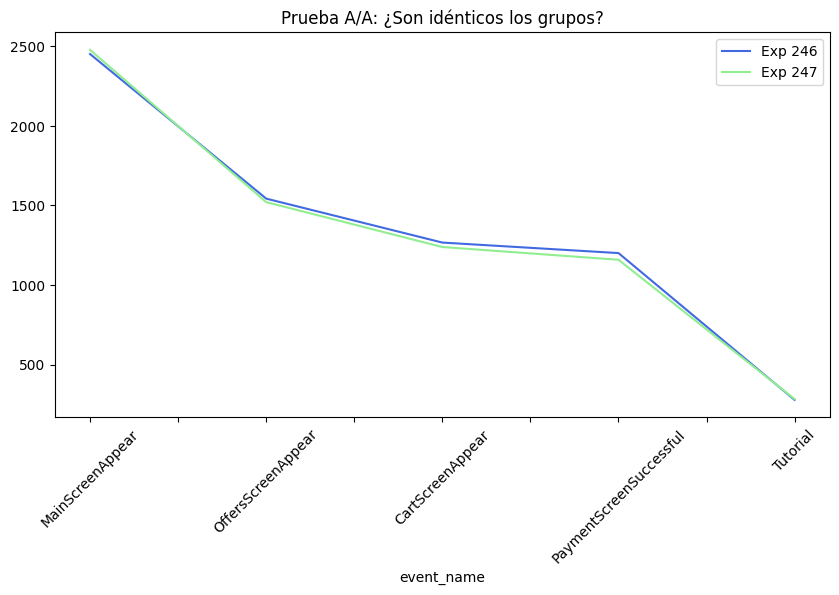

In [43]:
# Vamos a ver si las distribuciones se solapan (deberían ser casi iguales)
grupo_control_1 = df_filtered[df_filtered['exp_id'] == 246].groupby('event_name').agg({'user_id':'nunique'}).sort_values('user_id', ascending=False)['user_id']
grupo_control_2 = df_filtered[df_filtered['exp_id'] == 247].groupby('event_name').agg({'user_id':'nunique'}).sort_values('user_id', ascending=False)['user_id']

# VISUALIZACIÓN:
plt.figure(figsize=(10, 5))
grupo_control_1.plot(label='Exp 246', color='royalblue')
grupo_control_2.plot(label='Exp 247', color='lightgreen')
plt.title("Prueba A/A: ¿Son idénticos los grupos?")
plt.legend()
plt.xticks(rotation=45)
plt.show()

<b> Pruebas Z entre grupo 246 y 247 <b>

In [44]:
z_test_check(df_filtered, 246, 247, 'MainScreenAppear')
z_test_check(df_filtered, 246, 247, 'OffersScreenAppear')
z_test_check(df_filtered, 246, 247, 'CartScreenAppear')
z_test_check(df_filtered, 246, 247, 'PaymentScreenSuccessful')

Grupos: 246 vs 247
Evento: MainScreenAppear | p-value: 0.7571
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 246 vs 247
Evento: OffersScreenAppear | p-value: 0.2481
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 246 vs 247
Evento: CartScreenAppear | p-value: 0.2288
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 246 vs 247
Evento: PaymentScreenSuccessful | p-value: 0.1146
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)


<b> NOTA: <b>

    Hemos comprobado que no hay diferencia estadísticamente significativa entre los grupos 246 y 247.
    
    En el gráfico de lineas, se ve un comportamiento similar en ambos grupos y en los resultados de las pruebas Z, el valor p, nunca es menor que 0.05.

<b> Pruebas Z entre grupo 246 y 248 <b>

In [45]:
z_test_check(df_filtered, 246, 248, 'MainScreenAppear', alpha=0.1)
z_test_check(df_filtered, 246, 248, 'OffersScreenAppear', alpha=0.1)
z_test_check(df_filtered, 246, 248, 'CartScreenAppear', alpha=0.1)
z_test_check(df_filtered, 246, 248, 'PaymentScreenSuccessful', alpha=0.1)

Grupos: 246 vs 248
Evento: MainScreenAppear | p-value: 0.2950
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 246 vs 248
Evento: OffersScreenAppear | p-value: 0.2084
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 246 vs 248
Evento: CartScreenAppear | p-value: 0.0784
   🚨 ¡Diferencia Significativa detectada!
Grupos: 246 vs 248
Evento: PaymentScreenSuccessful | p-value: 0.2123
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)


<b> Pruebas Z entre grupo 247 y 248 <b>

In [46]:
z_test_check(df_filtered, 247, 248, 'MainScreenAppear', alpha=0.1)
z_test_check(df_filtered, 247, 248, 'OffersScreenAppear', alpha=0.1)
z_test_check(df_filtered, 247, 248, 'CartScreenAppear', alpha=0.1)
z_test_check(df_filtered, 247, 248, 'PaymentScreenSuccessful', alpha=0.1)

Grupos: 247 vs 248
Evento: MainScreenAppear | p-value: 0.4587
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 247 vs 248
Evento: OffersScreenAppear | p-value: 0.9198
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 247 vs 248
Evento: CartScreenAppear | p-value: 0.5786
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 247 vs 248
Evento: PaymentScreenSuccessful | p-value: 0.7373
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)


<b> Pruebas Z entre grupos de control combinados (246 y 247) y 248 <b>

In [47]:
z_test_check(df_filtered, [246, 247], 248, 'MainScreenAppear', alpha=0.1)
z_test_check(df_filtered, [246, 247], 248, 'OffersScreenAppear', alpha=0.1)
z_test_check(df_filtered, [246, 247], 248, 'CartScreenAppear', alpha=0.1)
z_test_check(df_filtered, [246, 247], 248, 'PaymentScreenSuccessful', alpha=0.1)


Grupos: [246, 247] vs 248
Evento: MainScreenAppear | p-value: 0.2942
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: [246, 247] vs 248
Evento: OffersScreenAppear | p-value: 0.4343
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: [246, 247] vs 248
Evento: CartScreenAppear | p-value: 0.1818
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: [246, 247] vs 248
Evento: PaymentScreenSuccessful | p-value: 0.6004
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)


<b>CONCLUSIONES INTERMEDIAS<b>

- Se estableció un `nivel de significancia de 0.10` para detectar diferencias sutiles entre los grupos para poder prestarles más atención.
- Aun con un nivel de significancia más "flexible", no hay diferencias estadisticamente significativas en la mayoría de las pruebas, solo hubo una diferencia estadísticamente significativa en el evento `CartScreenAppear` entre los grupos 246 y 248.
- Al realizar más de 10 pruebas, con un nivel de significancia de 0.1 es probable que al menos uno de estos resultados sea un `falso positivo` (Error tipo I).
- Además, al estar realizando 12 pruebas para determinar si el grupo con fuentes alteradas mostró alguna mejora, se debe aplicar un `método de correción` al nivel de significación.
- Para este caso se utilizará el `procedimiento de Bonferroni` cuya formula es la siguiente:
    alpha(corregido) = alpha / n_experimentos
Por lo tanto el alpha corregido sería igual a 0.1 / 12 = `0.0083`

<b>Segunda ronda de pruebas Z<b>

In [48]:
z_test_check(df_filtered, 246, 248, 'MainScreenAppear', alpha=0.0083)
z_test_check(df_filtered, 246, 248, 'OffersScreenAppear', alpha=0.0083)
z_test_check(df_filtered, 246, 248, 'CartScreenAppear', alpha=0.0083)
z_test_check(df_filtered, 246, 248, 'PaymentScreenSuccessful', alpha=0.0083)
z_test_check(df_filtered, 247, 248, 'MainScreenAppear', alpha=0.0083)
z_test_check(df_filtered, 247, 248, 'OffersScreenAppear', alpha=0.0083)
z_test_check(df_filtered, 247, 248, 'CartScreenAppear', alpha=0.0083)
z_test_check(df_filtered, 247, 248, 'PaymentScreenSuccessful', alpha=0.0083)
z_test_check(df_filtered, [246, 247], 248, 'MainScreenAppear', alpha=0.0083)
z_test_check(df_filtered, [246, 247], 248, 'OffersScreenAppear', alpha=0.0083)
z_test_check(df_filtered, [246, 247], 248, 'CartScreenAppear', alpha=0.0083)
z_test_check(df_filtered, [246, 247], 248, 'PaymentScreenSuccessful', alpha=0.0083)

Grupos: 246 vs 248
Evento: MainScreenAppear | p-value: 0.2950
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 246 vs 248
Evento: OffersScreenAppear | p-value: 0.2084
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 246 vs 248
Evento: CartScreenAppear | p-value: 0.0784
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 246 vs 248
Evento: PaymentScreenSuccessful | p-value: 0.2123
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 247 vs 248
Evento: MainScreenAppear | p-value: 0.4587
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 247 vs 248
Evento: OffersScreenAppear | p-value: 0.9198
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 247 vs 248
Evento: CartScreenAppear | p-value: 0.5786
   ✅ No hay diferencia significativa (Hipótesis Nula aceptada)
Grupos: 247 vs 248
Evento: PaymentScreenSuccessful | p-value: 0.7373
   ✅ No hay diferencia significativa (Hipótes

### 5.3. Conclusiones Finales

Finalmente concluimos que:

- No hay diferencia estadísticamente significativa entre los grupos de control `246` y `247`. Por lo tanto ambos muestran el comportamiento típico de los usuarios correctamente.
- El grupo con fuentes alteradas `248` no mostró diferencias estadísticamente significativas entre ninguno de los dos grupos de control.
- la prueba A/B mostró que el grupo con fuentes alteradas `no mejoró` las tasas de conversión de los usuarios en ninguna de las etapas del embudo de eventos.